# Задача 2

Исходная матрица A:
[[1.  0.5]
 [0.5 1. ]]
Настоящая обратная матрица:
[[ 1.33333333 -0.66666667]
 [-0.66666667  1.33333333]]

Тест для m = 1
Метод сошелся за 8 итераций.
Обратная матрица (метод Шульца):
[[ 1.33333333 -0.66666667]
 [-0.66666667  1.33333333]]
Проверка: A @ X_inv:
[[1.00000000e+00 4.01900735e-14]
 [4.01900735e-14 1.00000000e+00]]
Ошибка: 8.038014698286133e-14



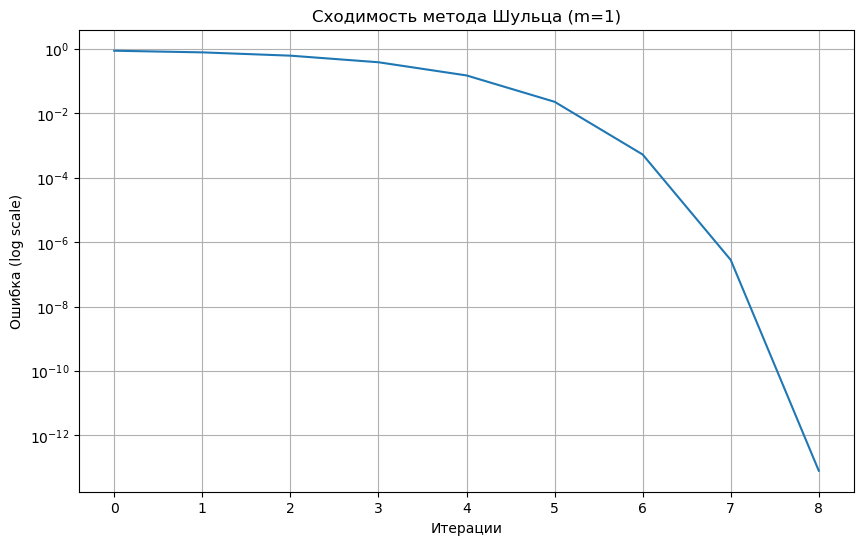

Тест для m = 2
Метод сошелся за 5 итераций.
Обратная матрица (метод Шульца):
[[ 1.33333333 -0.66666667]
 [-0.66666667  1.33333333]]
Проверка: A @ X_inv:
[[1.00000000e+00 1.85851334e-13]
 [1.85851334e-13 1.00000000e+00]]
Ошибка: 3.715916463420399e-13



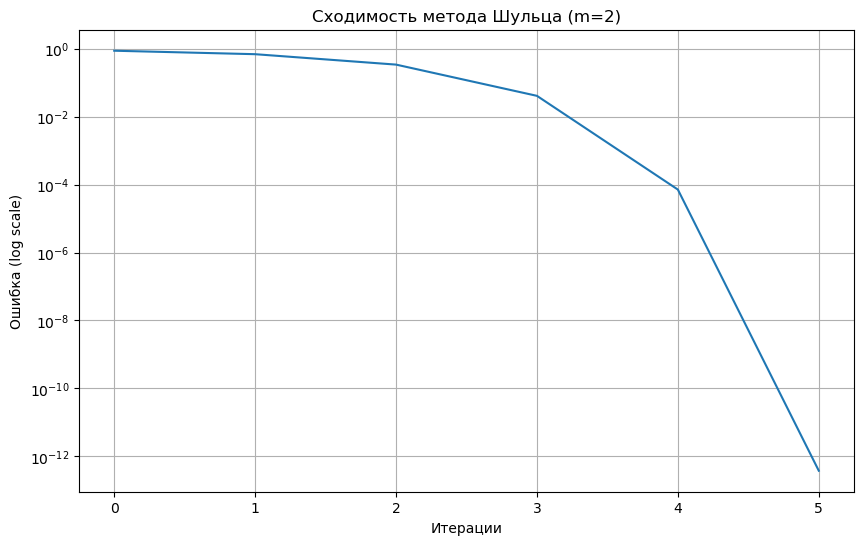

Тест для m = 3
Метод сошелся за 4 итераций.
Обратная матрица (метод Шульца):
[[ 1.33333333 -0.66666667]
 [-0.66666667  1.33333333]]
Проверка: A @ X_inv:
[[1.00000000e+00 4.01900735e-14]
 [4.01900735e-14 1.00000000e+00]]
Ошибка: 8.038014698286133e-14



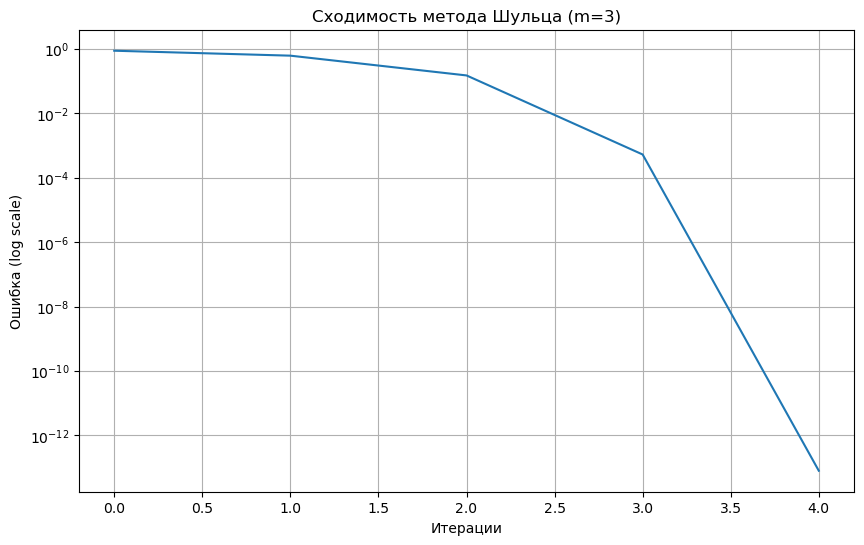

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def shultz_method(A, tol=1e-6, max_iter=1000, m=1):
    n, _ = A.shape
    
    # Начальное приближение
    norm_1 = np.linalg.norm(A, ord=1)
    norm_inf = np.linalg.norm(A, ord=np.inf)
    X = A.T / (norm_1 * norm_inf)
    
    E = np.eye(n)
    Psi = E - A @ X

    # Проверяем сходимость начального приближения
    if np.linalg.norm(Psi, ord=np.inf) >= 1:
        raise ValueError("Метод не сходится: норма первой невязки больше или равна единице.")
    
    errors = []
    for k in range(max_iter):
        error = np.linalg.norm(Psi, ord=np.inf)
        errors.append(error)
        
        if error < tol:
            print(f"Метод сошелся за {k} итераций.")
            return X, errors
        
        # Вычисляем сумму степеней Psi
        Psi_sum = sum(np.linalg.matrix_power(Psi, i) for i in range(m+1))
        
        X = X @ Psi_sum
        Psi = E - A @ X
    
    raise ValueError("Метод не сошелся за заданное количество итераций.")

def plot_convergence(errors, m):
    plt.figure(figsize=(10, 6))
    plt.semilogy(errors)
    plt.title(f'Сходимость метода Шульца (m={m})')
    plt.xlabel('Итерации')
    plt.ylabel('Ошибка (log scale)')
    plt.grid(True)
    plt.show()

def test_shultz_method(A, tol=1e-6, max_iter=1000, m_values=[1, 2, 3]):
    print(f"Исходная матрица A:\n{A}")
    print(f"Настоящая обратная матрица:\n{np.linalg.inv(A)}\n")
    
    for m in m_values:
        print(f"Тест для m = {m}")
        try:
            X_inv, errors = shultz_method(A, tol, max_iter, m)
            print(f"Обратная матрица (метод Шульца):\n{X_inv}")
            print(f"Проверка: A @ X_inv:\n{A @ X_inv}")
            print(f"Ошибка: {np.linalg.norm(E - A @ X_inv, ord=np.inf)}\n")
            plot_convergence(errors, m)
        except ValueError as e:
            print(f"Ошибка: {e}\n")

# Тестовая матрица
A = np.array([[1, 0.5], [0.5, 1]], dtype=float)
E = np.eye(A.shape[0])

test_shultz_method(A, tol=1e-10, max_iter=100, m_values=[1, 2, 3])


# Задача 3

Введём матрицу 
 поворота Гивенса (она единичная, за исключением строк 
, в которых только два ненулевых элемента):

 
  
где 
 и 
 для некоторого 
. Таким образом, матрица поворота Гивенса 
 - ортогональна.

Пусть есть произвольная 
.

Какие элементы матрицы 
 поменяются при домножении 
 слева на 
?
Какие 
 надо выбрать, чтобы по гарантировать зануление элемента 
 после такого перемножения? Не забывайте, что 
 должна быть ортогональной.
Учитывая ортогональность всех матриц Гивенса (а домножение ортогональной на ортогональную есть ортогональная), постройте алгоритм построения QR-разложения матрицы 
.

Доказать, что метод Гивенса реализует QR-разложение матрицы.



$$
A=Q R,
$$
где $Q$ - ортогональная матрица, а $R-$ верхняя треугольная с положительными элементами на главной диагонали.


1. Какие элементы матрицы A поменяются при домножении G(k, l, \theta)^T слева на A?

При умножении G(k, l, \theta)^T слева на матрицу A изменяются только элементы A в строках k и l. Все остальные строки остаются неизменными, поскольку матрица Гивенса G является единичной с точностью до строк k и l.

2. Какие k, l, s, c надо выбрать, чтобы гарантировать зануление элемента i, j (i > j) после такого перемножения?

Чтобы занулить элемент $A_{i,j}$ в строке i, j-ом столбце (где i > j), необходимо:
	•	Выбрать k = j и l = i, т.е. работать с элементами $A_{k,j} и A_{l,j}$, где k — строка выше l.
	•	Подобрать значения $s = \sin\theta$ и $c = \cos\theta$, чтобы после поворота элемент $A_{l,j} $занулился.

Формулы для вычисления c и s таковы:

$r = \sqrt{A_{k,j}^2 + A_{l,j}^2}, \quad c = \frac{A_{k,j}}{r}, \quad s = \frac{A_{l,j}}{r}.$


После применения$ G(k, l, \theta), элемент A_{l,j}$ занулится.

3. Постройте алгоритм построения QR-разложения матрицы A:

QR-разложение с использованием матриц Гивенса можно построить следующим образом:

Алгоритм:

		Пусть A — матрица размера $n \times n.$
		Инициализировать матрицу Q как единичную матрицу I_n.
		Для каждого столбца j от 1 до n-1:
	    Для каждой строки i ниже j (т.е. i > j), где A_{i,j} \neq 0:
		Вычислить параметры c и s для поворота Гивенса:

$r = \sqrt{A_{j,j}^2 + A_{i,j}^2}, \quad c = \frac{A_{j,j}}{r}, \quad s = \frac{A_{i,j}}{r}.$

		Построить матрицу Гивенса G(k, l, \theta), где k = j, l = i.
		Обновить матрицу A путём умножения G(k, l, \theta)^T слева:

$A = G(k, l, \theta)^T A.$

		Обновить матрицу Q путём умножения $G(k, l, \theta)$ справа:

$Q = Q G(k, l, \theta).$

		После всех итераций:
	Q будет ортогональной матрицей.
	A станет верхнетреугольной матрицей R.

Результат:

На выходе получаем QR-разложение:

A = Q R,

где Q — ортогональная матрица, а R — верхнетреугольная матрица.

In [2]:
import numpy as np

def givens_rotation(a, b):
    r = np.sqrt(a**2 + b**2)
    c = a / r
    s = -b / r
    return c, s

def qr_decomposition(A):
    m, n = A.shape
    Q = np.eye(m)
    R = A.copy()

    for j in range(n):
        for i in range(j+1, m):
            if R[i, j] != 0:
                c, s = givens_rotation(R[j, j], R[i, j])
                
                G = np.eye(m)
                G[j, j] = G[i, i] = c
                G[j, i] = s
                G[i, j] = -s
                
                R = G.T @ R
                Q = Q @ G

    return Q, R


In [3]:
import numpy as np

# Создаем случайную матрицу для тестирования
A = np.random.rand(5, 5)

# Применяем вашу функцию QR-разложения
Q, R = qr_decomposition(A)

# Проверки
print("Проверка ортогональности Q:")
print(np.allclose(Q.T @ Q, np.eye(Q.shape[1])))

print("\nПроверка верхней треугольности R:")
print(np.allclose(np.triu(R), R))

print("\nПроверка разложения A = QR:")
print(np.allclose(A, Q @ R))

print("\nСравнение с numpy.linalg.qr:")
Q_np, R_np = np.linalg.qr(A)
print("Разница в Q:", np.linalg.norm(abs(Q) - abs(Q_np)))
print("Разница в R:", np.linalg.norm(abs(R) - abs(R_np)))


Проверка ортогональности Q:
True

Проверка верхней треугольности R:
True

Проверка разложения A = QR:
True

Сравнение с numpy.linalg.qr:
Разница в Q: 1.5007273159926268e-15
Разница в R: 7.288481507904163e-16


# Задача 4

Покажите, что при больших n метод Гивенса требует
$$
\approx 4 n^3 / 3
$$
  действий умножения.  Докажите, что метод Гаусса требует примерно в 4 раза меньше.  


.


Для каждого столбца  j  (от 1 до  n-1 ) требуется занулить элементы ниже диагонали в строках  i > j .
	•	В каждом столбце  j  нужно применить  n-j  вращений, чтобы занулить элементы от  j+1 -ой строки до  n -ой строки.

    Таким образом, общее количество вращений (попарных преобразований Гивенса) будет равно:


$\text{Общее число вращений} = \sum_{j=1}^{n-1} (n - j) = \frac{n(n-1)}{2}.$


Сложность одного вращения Гивенса

Каждое вращение  $G(k, l, \theta)$  изменяет только две строки матрицы  A  из  n  строк. Обновление двух строк требует  2n  умножений.

Таким образом, сложность одного вращения —  O(2n)  операций умножения.



$\text{Общее число умножений} = \text{(число вращений)} \times \text{(операции на одно вращение)}.$


Подставим значения:


$\text{Общее число умножений} = \frac{n(n-1)}{2} \cdot 2n = n^3 - \frac{n^2}{2}.$


Для больших  n ,  $\frac{n^2}{2} $ можно пренебречь. Таким образом:


$\text{Общее число умножений} \approx n^3.$


Метод Гаусса для приведения матрицы  A  к верхнетреугольному виду выполняется следующим образом:
	1.	Для каждого столбца  j  от 1 до  n-1 :
	•	Обновляются элементы всех строк ниже  j -ой строки.

Считаем, сколько операций требуется для каждого шага:
	•	На  j -ом шаге в столбце  j  обновляются  n-j  строк, а в каждой строке нужно обновить  n-j  элементов матрицы.
	•	Каждое обновление требует одного умножения и одного вычитания.

Суммарная сложность метода Гаусса

Общее количество операций для всех шагов:


$\text{Общее число умножений} = \sum_{j=1}^{n-1} (n-j)^2.$


Развернем сумму:


$\text{Общее число умножений} = \sum_{j=1}^{n-1} (n^2 - 2jn + j^2).$

Первая сумма:  $\sum_{j=1}^{n-1} n^2 = n^2 (n-1) ,$
Вторая сумма:  $\sum_{j=1}^{n-1} 2jn = n(n-1)(n+1)/3 ,$
Третья сумма:  $\sum_{j=1}^{n-1} j^2 = \frac{(n-1)n(2n-1)}{6} .$

Складывая и упрощая, получаем:


$\text{Общее число умножений} \approx \frac{n^3}{3}.$
